In [1]:
import sys
from scipy.io import mmread
import os
import glob
import pandas as pd
import numpy as np
#from pandas_ods_reader import read_ods
from copy import deepcopy
import pprint
import json
import re
from datetime import datetime
import logging
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor
from sklearn import preprocessing
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
from sklearn.manifold import TSNE
from sklearn import metrics
from sklearn.cluster import DBSCAN
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from collections import Counter
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import harmonypy as hm
from matplotlib.cm import ScalarMappable
from datetime import date
import mpld3
import hvplot.pandas
import holoviews as hv
from holoviews import opts
import panel as pn
import bokeh
from bokeh.resources import INLINE
from adjustText import adjust_text
from scipy.stats import mannwhitneyu, false_discovery_control, wilcoxon, pearsonr
import pygwalker as pyg
import matplotlib as mpl 
import PyPDF2
from PyPDF2 import PdfFileReader, PdfFileWriter, PdfReader, PdfWriter
from matplotlib.backends.backend_pdf import PdfPages
from pdf2image import convert_from_path
from scipy.cluster.hierarchy import dendrogram, linkage, optimal_leaf_ordering, leaves_list
import fitz  # PyMuPDF
from marsilea.plotter import SizedMesh

import corr_analysis as ca
import dimorph_processing as dp
import cell_comparison as cc
import sex_stats as ss
import run_corr_analysis as rca
import spin as spin
 

today = str(date.today())
%matplotlib notebook
%load_ext autoreload
%autoreload 2

#change matplotlib font type to make compatibile with illustrator
#mpl.rcParams['pdf.fonttype'] = 42
#mpl.rcParams['ps.fonttype'] = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
IEG_updated_list = []
with open('/bigdata/isaac/IEG_updated_list.txt', 'r') as fh:
    for g in fh:
        IEG_updated_list.append(g[:-1])
IEG_updated_list

['Bdnf',
 'Homer1',
 'Fos',
 'Arc',
 'Btg2',
 'Fosl2',
 'Npas4',
 'Nr4a1',
 'Fosb',
 'Junb',
 'Egr1',
 'Egr2',
 'Egr4',
 'Nr4a3',
 'Dusp1',
 'Dusp6',
 'Cdkn1a',
 'Gadd45b',
 'Inhba']

In [103]:
run = '050325_run_IEG'
cell_class = 'gaba'
delta_data_folder = '/bigdata/isaac/'+ cell_class + '_files/sex_stats/'+run+'/gene_delta_plots/data/'
genes = IEG_updated_list
gene_subset_name = 'IEG'
outfolder = '/bigdata/isaac/'+ cell_class + '_files/sex_stats/'+run +'/' + gene_subset_name + '_corr_plots/'
os.makedirs(outfolder, exist_ok=True)

# Change the current working directory to the specified path
os.chdir(delta_data_folder)

# Get a list of all files in the directory that include '_expr_mlog_df_c_'
raw_files = [f for f in os.listdir() if '_expr_raw_df_c_' in f]
metadata_files= [f for f in os.listdir() if '_metadata_df_c_' in f]

def extract_number(filename):
    match = re.search(r'-(\d+)-', filename)
    if match:
        return int(match.group(1))
    return float('inf')  # In case no number is found, place it at the end


# Sort the lists based on the extracted number
sorted_raw_files = sorted(raw_files, key=extract_number)
sorted_metadata_files = sorted(metadata_files, key=extract_number)

print ('sorted raw files/metadata files')
print(sorted_raw_files)
print(sorted_metadata_files)

sorted raw files/metadata files
['gaba_expr_raw_df_c_GABA-1-Sst-Npy-Spon1.json', 'gaba_expr_raw_df_c_GABA-2-Sst-Npy-Maf.json', 'gaba_expr_raw_df_c_GABA-3-Sst-Npy-Chodl.json', 'gaba_expr_raw_df_c_GABA-4-Moxd1-Pvalb.json', 'gaba_expr_raw_df_c_GABA-5-Moxd1-Vwc2.json', 'gaba_expr_raw_df_c_GABA-6-Hapln1-Cryab.json', 'gaba_expr_raw_df_c_GABA-7-Vip-Crh.json', 'gaba_expr_raw_df_c_GABA-8-Htr3a-Rgs12.json', 'gaba_expr_raw_df_c_GABA-9-Dab1-Myh7.json', 'gaba_expr_raw_df_c_GABA-10-Pax6-Npnt.json', 'gaba_expr_raw_df_c_GABA-11-Pax6-Calca.json', 'gaba_expr_raw_df_c_GABA-12-Sncg-Reln.json', 'gaba_expr_raw_df_c_GABA-13-Fign-Lrpprc.json', 'gaba_expr_raw_df_c_GABA-14-Isl1-Gal.json', 'gaba_expr_raw_df_c_GABA-15-Igsf1-Zfhx3.json', 'gaba_expr_raw_df_c_GABA-16-Lmo1-Chn2.json', 'gaba_expr_raw_df_c_GABA-17-Isl1-Pou3f2.json', 'gaba_expr_raw_df_c_GABA-18-Meis2-Dach1.json', 'gaba_expr_raw_df_c_GABA-19-Meis2-Tshz1.json', 'gaba_expr_raw_df_c_GABA-20-Meis2-Foxp2.json', 'gaba_expr_raw_df_c_GABA-21-Meis2-Nwd2.json', 'g

In [5]:
scores_df = pd.DataFrame(columns=['fn','b_f','b_m','n_f','n_m'])

In [6]:
genes

['Bdnf',
 'Homer1',
 'Fos',
 'Arc',
 'Btg2',
 'Fosl2',
 'Npas4',
 'Nr4a1',
 'Fosb',
 'Junb',
 'Egr1',
 'Egr2',
 'Egr4',
 'Nr4a3',
 'Dusp1',
 'Dusp6',
 'Cdkn1a',
 'Gadd45b',
 'Inhba']

In [21]:
sorted_raw_files[1]

'gaba_expr_raw_df_c_GABA-2-Sst-Npy-Maf.json'

In [ ]:
#debug single cell type

scores_df = pd.DataFrame(columns=['fn','b_f','b_m','n_f','n_m'])
counts_df = pd.DataFrame(columns=['fn','b_f','b_m','n_f','n_m'])

data_file = sorted_raw_files[1]
metadata_file = sorted_metadata_files[1]
print (data_file)
raw_df = pd.read_json(data_file)
metadata_df = pd.read_json(metadata_file)

#ensure that the columns are the same
if np.all(raw_df.columns == metadata_df.columns) != True:
    print('error: columns are not the same')
    
#get filename
x = data_file.split('_')
fn = x[-1].split('.')[0]
print('processing: ', fn)

#check if the gene is in the raw_df
missing_genes = []
for g in genes:
    if g in raw_df.index:
        pass
    else:
        print (g, 'not in raw_df')
        missing_genes.append(g)

#print ('missing genes:', missing_genes)
#drop missing genes from original gene list
if len(missing_genes)>0:
    print ('removing missing genes from gene list')
    genes = [x for x in genes if x not in missing_genes]

#subset the raw_df to only include specified genes
subset_df = raw_df.loc[genes,:]

#drop rows with all zeros
#subset_df = subset_df.loc[~(subset_df == 0).all(axis=1)]

#get subset of cells for each group
b_f_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Breeder-F']
b_m_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Breeder-M']
n_f_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Naïve-F']   
n_m_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Naïve-M'] 

#check group sizes
cutoff = 20
if b_f_subset_df.shape[1] <cutoff or b_m_subset_df.shape[1] <cutoff  or n_f_subset_df.shape[1] <cutoff or n_m_subset_df.shape[1] < cutoff:
    print ('one or more groups has <20 cells, skipping...')

else:
    #use 90% quantile. i.e. 90% of cells have a value < this
    #this is the threshold for each gene
    #thresh_df = subset_df.quantile(0.90, axis = 1) 
    #simple case - make thresh 0 for all genes
    thresh = 0
    #thresh_df = np.floor(subset_df.quantile(0.90, axis = 1))
    print (thresh_df)
    
    frac_df = pd.DataFrame(index = subset_df.index, columns = ['b_f','b_m','n_f','n_m'])
    frac_df.loc[:,'b_f'] = (b_f_subset_df>0).sum(axis=1)/b_f_subset_df.shape[1]
    frac_df.loc[:,'b_m'] = (b_m_subset_df>0).sum(axis=1)/b_m_subset_df.shape[1]
    frac_df.loc[:,'n_f'] = (n_f_subset_df>0).sum(axis=1)/n_f_subset_df.shape[1]
    frac_df.loc[:,'n_m'] = (n_m_subset_df>0).sum(axis=1)/n_m_subset_df.shape[1]


    #calculate the fraction of cells above the threshold
    #for g in genes:
        #b_f_frac = (b_f_subset_df.loc[g,:] > thresh_df.loc[g]).sum()/b_f_subset_df.shape[1]
        #b_m_frac = (b_m_subset_df.loc[g,:] > thresh_df.loc[g]).sum()/b_m_subset_df.shape[1]
        #n_f_frac = (n_f_subset_df.loc[g,:] > thresh_df.loc[g]).sum()/n_f_subset_df.shape[1]
        #n_m_frac = (n_m_subset_df.loc[g,:] > thresh_df.loc[g]).sum()/n_m_subset_df.shape[1]
        
        #frac_df.loc[g,'b_f'] = b_f_frac
        #frac_df.loc[g,'b_m'] = b_m_frac
        #frac_df.loc[g,'n_f'] = n_f_frac
        #frac_df.loc[g,'n_m'] = n_m_frac

    #print (frac_df)
    tmp_score = pd.DataFrame({"fn": fn,
                            "b_f": frac_df.sum(axis=0)[0],
                            "b_m": frac_df.sum(axis=0)[1],
                            "n_f": frac_df.sum(axis=0)[2],
                            "n_m": frac_df.sum(axis=0)[3]}, index=[0])

    scores_df = pd.concat([scores_df,tmp_score],axis=0)

    #get counts and add to counts_df
    b_f_count = b_f_subset_df.shape[1]
    b_m_count = b_m_subset_df.shape[1]
    n_f_count = n_f_subset_df.shape[1]
    n_m_count = n_m_subset_df.shape[1]
    tmp_count = np.array([fn, b_f_count, b_m_count, n_f_count, n_m_count])
    tmp_count = np.reshape(tmp_count, (1, len(tmp_count)))
    count_df = pd.DataFrame(tmp_count, columns=counts_df.columns)
    counts_df = pd.concat([counts_df,count_df],axis=0)



gaba_expr_raw_df_c_GABA-2-Sst-Npy-Maf.json
processing:  GABA-2-Sst-Npy-Maf
Bdnf       0.0
Homer1     3.0
Fos        0.0
Arc        0.0
Btg2       0.0
Fosl2      0.0
Npas4      0.0
Nr4a1      0.0
Fosb       0.0
Junb       3.0
Egr1       3.0
Egr2       0.0
Egr4       0.0
Nr4a3      0.0
Dusp1      2.0
Dusp6      0.0
Cdkn1a     1.0
Gadd45b    0.0
Inhba      0.0
Name: 0.9, dtype: float64


In [106]:
gaba_thresh

Bdnf        0
Homer1      3
Fos         3
Arc         0
Btg2        2
Fosl2       0
Npas4       0
Nr4a1       0
Fosb        0
Junb        6
Egr1       10
Egr2        0
Egr4        2
Nr4a3       0
Dusp1       1
Dusp6       0
Cdkn1a      0
Gadd45b     0
Inhba       0
Name: 0.9, dtype: object

In [7]:
b_f_subset_df

,TTCTAACAGAGATCGC-1_10X52_1,CGCGTGACATCAGCGC-1_10X51_1,GACGCTGGTGACTATC-1_10X52_1,TGAGGAGCATTCGATG-1_10X52_1,TTCCAATTCCATTGCC-1_10X51_2,ACCTGTCAGCTGACTT-1_10X51_2,TAGTGCAGTGCGGTAA-1_10X52_2,AGTCATGGTAAGCTCT-1_10X52_2,GTTTACTGTAGCCAGA-1_10X52_1,TCTTAGTAGTCGGGAT-1_10X52_1,...,GGTTCTCGTGTTGACT-1_10X51_2,CGTAATGCATTGTGCA-1_10X51_2,ACACGCGTCCCTTGTG-1_10X51_2,ACGATCAGTTGGGATG-1_10X51_1,AGACCATTCTAGTGTG-1_10X52_2,AAAGTCCCAGAGAATT-1_10X52_2,ATGGGTTAGACTTCAC-1_10X52_1,ACCTACCGTATTTCCT-1_10X52_1,ATACTTCCAGCCCACA-1_10X51_2,ATCCACCCACCTATCC-1_10X52_1
Bdnf,0.0,0.00000,0.0,0.0,0.00000,0.00000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Homer1,0.0,0.00000,0.0,0.0,0.00000,0.00000,0.000000,0.0,0.0,0.000000,...,2.936858,6.418485,3.491620,1.567521,2.670584,0.000000,1.797914,0.000000,3.044603,0.000000
Fos,0.0,0.00000,0.0,0.0,0.00000,0.00000,0.000000,0.0,0.0,0.000000,...,0.000000,1.283697,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Arc,0.0,0.00000,0.0,0.0,3.86922,0.00000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.291823
Btg2,0.0,0.00000,0.0,0.0,0.00000,0.00000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Fosl2,0.0,0.00000,0.0,0.0,0.00000,0.00000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Npas4,0.0,0.00000,0.0,0.0,0.00000,4.07332,0.000000,0.0,0.0,4.110997,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Nr4a1,0.0,0.00000,0.0,0.0,0.00000,0.00000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Fosb,0.0,0.00000,0.0,0.0,0.00000,0.00000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.797914,0.000000,1.014868,0.000000
Junb,0.0,5.44514,0.0,0.0,0.00000,0.00000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,1.163873,1.567521,0.000000,0.000000,3.595829,0.000000,0.000000,1.291823


In [14]:
frac_df.loc[:,'b_f'] = (b_f_subset_df>0).sum(axis=1)/b_f_subset_df.shape[1]

In [15]:
frac_df.loc[:,'b_f']

Bdnf       0.016129
Homer1     0.354839
Fos        0.112903
Arc        0.048387
Btg2       0.016129
Fosl2      0.016129
Npas4      0.048387
Nr4a1           0.0
Fosb       0.032258
Junb       0.241935
Egr1       0.290323
Egr2            0.0
Egr4       0.048387
Nr4a3      0.032258
Dusp1      0.129032
Dusp6      0.032258
Cdkn1a      0.16129
Gadd45b    0.032258
Inhba           0.0
Name: b_f, dtype: object

In [ ]:
scores_df = pd.DataFrame(columns=['fn','b_f','b_m','n_f','n_m'])
counts_df = pd.DataFrame(columns=['fn','b_f','b_m','n_f','n_m'])




for data_file, metadata_file in zip(sorted_raw_files, sorted_metadata_files):
    print (f'processing cell type: {data_file}')   
    raw_df = pd.read_json(data_file)
    metadata_df = pd.read_json(metadata_file)

    #ensure that the columns are the same
    if np.all(raw_df.columns == metadata_df.columns) != True:
        print('error: columns are not the same')
        
    #get filename
    x = data_file.split('_')
    fn = x[-1].split('.')[0]
    print('processing: ', fn)

    #check if the gene is in the raw_df
    missing_genes = []
    for g in genes:
        if g in raw_df.index:
            pass
        else:
            print (g, 'not in raw_df')
            missing_genes.append(g)

    #print ('missing genes:', missing_genes)
    #drop missing genes from original gene list
    if len(missing_genes)>0:
        print ('removing missing genes from gene list')
        genes = [x for x in genes if x not in missing_genes]

    #subset the raw_df to only include specified genes
    subset_df = raw_df.loc[genes,:]

    #drop rows with all zeros
    #subset_df = subset_df.loc[~(subset_df == 0).all(axis=1)]

    #get subset of cells for each group
    b_f_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Breeder-F']
    b_m_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Breeder-M']
    n_f_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Naïve-F']   
    n_m_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Naïve-M'] 

    #check group sizes
    cutoff = 20
    if b_f_subset_df.shape[1] <cutoff or b_m_subset_df.shape[1] <cutoff  or n_f_subset_df.shape[1] <cutoff or n_m_subset_df.shape[1] < cutoff:
        print ('one or more groups has <20 cells, skipping...')

    else:
        #use 90% quantile. i.e. 90% of cells have a value < this
        #this is the threshold for each gene
        #thresh = 0
        thresh_df = subset_df.quantile(0.90, axis = 1) 
        #print (thresh)
        frac_df = pd.DataFrame(index = subset_df.index, columns = ['b_f','b_m','n_f','n_m'])
        frac_df.loc[:,'b_f'] = (b_f_subset_df>0).sum(axis=1)/b_f_subset_df.shape[1]
        frac_df.loc[:,'b_m'] = (b_m_subset_df>0).sum(axis=1)/b_m_subset_df.shape[1]
        frac_df.loc[:,'n_f'] = (n_f_subset_df>0).sum(axis=1)/n_f_subset_df.shape[1]
        frac_df.loc[:,'n_m'] = (n_m_subset_df>0).sum(axis=1)/n_m_subset_df.shape[1]


        tmp_score = pd.DataFrame({"fn": fn,
                                "b_f": frac_df.sum(axis=0)[0],
                                "b_m": frac_df.sum(axis=0)[1],
                                "n_f": frac_df.sum(axis=0)[2],
                                "n_m": frac_df.sum(axis=0)[3]}, index=[0])

        scores_df = pd.concat([scores_df,tmp_score],axis=0)

        #get counts and add to counts_df
        b_f_count = b_f_subset_df.shape[1]
        b_m_count = b_m_subset_df.shape[1]
        n_f_count = n_f_subset_df.shape[1]
        n_m_count = n_m_subset_df.shape[1]
        tmp_count = np.array([fn, b_f_count, b_m_count, n_f_count, n_m_count])
        tmp_count = np.reshape(tmp_count, (1, len(tmp_count)))
        count_df = pd.DataFrame(tmp_count, columns=counts_df.columns)
        counts_df = pd.concat([counts_df,count_df],axis=0)


processing cell type: gaba_expr_raw_df_c_GABA-1-Sst-Npy-Spon1.json
processing:  GABA-1-Sst-Npy-Spon1
processing cell type: gaba_expr_raw_df_c_GABA-2-Sst-Npy-Maf.json
processing:  GABA-2-Sst-Npy-Maf
processing cell type: gaba_expr_raw_df_c_GABA-3-Sst-Npy-Chodl.json
processing:  GABA-3-Sst-Npy-Chodl
one or more groups has <20 cells, skipping...
processing cell type: gaba_expr_raw_df_c_GABA-4-Moxd1-Pvalb.json
processing:  GABA-4-Moxd1-Pvalb
processing cell type: gaba_expr_raw_df_c_GABA-5-Moxd1-Vwc2.json
processing:  GABA-5-Moxd1-Vwc2
processing cell type: gaba_expr_raw_df_c_GABA-6-Hapln1-Cryab.json
processing:  GABA-6-Hapln1-Cryab
one or more groups has <20 cells, skipping...
processing cell type: gaba_expr_raw_df_c_GABA-7-Vip-Crh.json
processing:  GABA-7-Vip-Crh
processing cell type: gaba_expr_raw_df_c_GABA-8-Htr3a-Rgs12.json
processing:  GABA-8-Htr3a-Rgs12
processing cell type: gaba_expr_raw_df_c_GABA-9-Dab1-Myh7.json
processing:  GABA-9-Dab1-Myh7
processing cell type: gaba_expr_raw_df_

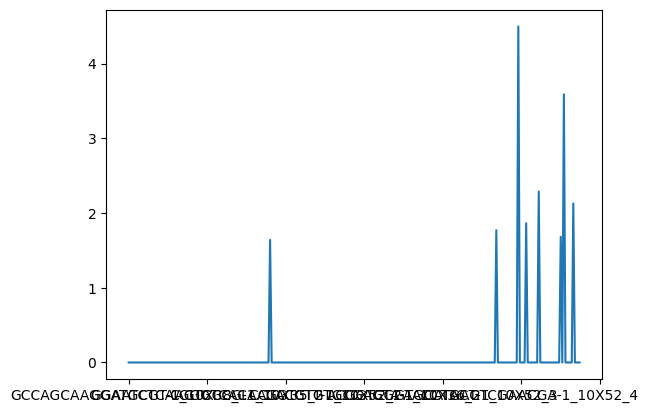

In [38]:
subset_df.loc['Bdnf',:].plot(kind='line')
plt.show()

In [32]:
np.percentile(np.array(subset_df.loc['Bdnf',:]),90)

0.0

In [ ]:
scores_df.set_index('fn', inplace=True)
counts_df.set_index('fn', inplace=True)
counts_df = counts_df.astype('int')

In [ ]:
#format cell counts
#counts_df = counts_df.set_index('fn')
#counts_df = counts_df.astype('int')

In [22]:
scores_df

,b_f,b_m,n_f,n_m
fn,,,,
GABA-1-Sst-Npy-Spon1,1.735632,1.637255,1.916667,1.972603
GABA-2-Sst-Npy-Maf,1.612903,1.714286,1.939394,1.826087
GABA-4-Moxd1-Pvalb,1.610390,1.960317,2.309524,2.380000
GABA-5-Moxd1-Vwc2,1.563636,2.103448,1.968750,1.818182
GABA-7-Vip-Crh,1.842105,2.694444,2.563636,1.787500
GABA-8-Htr3a-Rgs12,1.285714,0.979167,1.388060,1.269231
GABA-9-Dab1-Myh7,3.411321,3.950413,4.888889,4.033557
GABA-10-Pax6-Npnt,2.468085,2.566667,2.111111,2.531250
GABA-11-Pax6-Calca,1.764706,1.533333,2.181818,1.642857


In [23]:
counts_df

,b_f,b_m,n_f,n_m
fn,,,,
GABA-1-Sst-Npy-Spon1,87,102,72,73
GABA-2-Sst-Npy-Maf,62,91,66,69
GABA-4-Moxd1-Pvalb,77,126,84,50
GABA-5-Moxd1-Vwc2,55,58,32,33
GABA-7-Vip-Crh,57,36,110,80
GABA-8-Htr3a-Rgs12,49,48,67,52
GABA-9-Dab1-Myh7,265,121,153,149
GABA-10-Pax6-Npnt,47,30,36,32
GABA-11-Pax6-Calca,51,30,33,42


In [24]:
outfolder

'/bigdata/isaac/gaba_files/sex_stats/050325_run_IEG/IEG_corr_plots/'

In [30]:
gene_subset_name

'IEG'

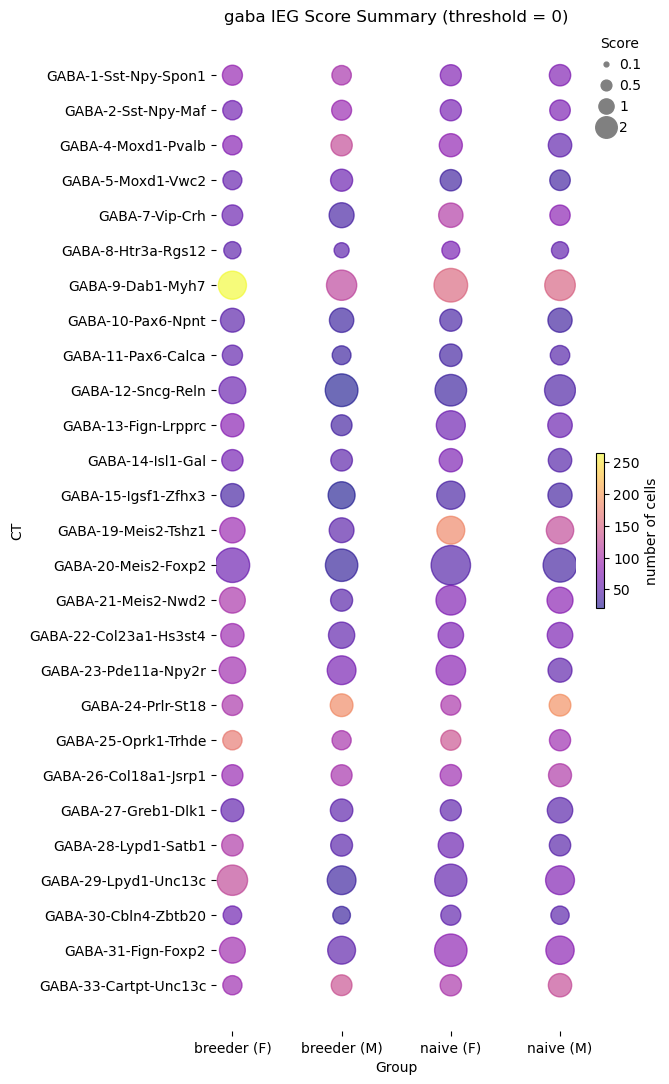

In [31]:
%matplotlib inline
fig, ax = plt.subplots(figsize = (5,scores_df.values.shape[0]//2))
# Create meshgrid for x, y coordinates
x, y = np.meshgrid(np.arange(scores_df.values.shape[1]), np.arange(scores_df.values.shape[0]))

# Flatten the data array to match the shape of x and y
data_flat = scores_df.values.flatten()
counts_flat = counts_df.values.flatten()
# Plot scatter with size proportional to data values
p = ax.scatter(x, y, s=data_flat*120, c=counts_flat, cmap = 'plasma', alpha=0.6)
ax.set_ylabel('CT')
ax.set_xlabel('Group')
ax.set_yticks(np.arange(len(scores_df.index)))
ax.set_yticklabels(list(scores_df.index))
ax.set_xticks(np.arange(len(scores_df.columns)))
ax.set_xticklabels(['breeder (F)', 'breeder (M)', 'naive (F)', 'naive (M)'])
plt.colorbar(p, ax=ax, fraction = 0.02, label = 'number of cells')
ax.invert_yaxis()
# Remove border
ax.set_frame_on(False)
# Add size legend
sizes = [0.1, 0.5, 1, 2]  # Desired data values
size_scaled = [s * 120 for s in sizes]  # Match scaling from s=data*500
legend_elements = [plt.scatter([], [], s=s, label=f'{v}', c='gray') for s, v in zip(size_scaled, sizes)]
ax.legend(handles=legend_elements, title='Score', loc='upper right', bbox_to_anchor=(1.2, 1))

ax.set_title(cell_class + ' ' + gene_subset_name + ' Score Summary (threshold = 0)')
plt.savefig(outfolder + cell_class + '_' + gene_subset_name + 't0_score_summary.pdf',bbox_inches='tight')
#plt.tight_layout()
plt.show()

sorted raw files/metadata files
['Vglut2_expr_raw_df_c_Vglut2-1-Trh-Tes.json', 'Vglut2_expr_raw_df_c_Vglut2-2-Synpr-Sox6.json', 'Vglut2_expr_raw_df_c_Vglut2-3-Tshz1-Tgfb2.json', 'Vglut2_expr_raw_df_c_Vglut2-4-Otp-Crabp1.json', 'Vglut2_expr_raw_df_c_Vglut2-5-Otp-Peg10.json', 'Vglut2_expr_raw_df_c_Vglut2-6-Otp-Zic5.json', 'Vglut2_expr_raw_df_c_Vglut2-7-Otp-Prlr.json', 'Vglut2_expr_raw_df_c_Vglut2-8-Arhgef40-Thrsp.json', 'Vglut2_expr_raw_df_c_Vglut2-9-Epha4-Penk.json', 'Vglut2_expr_raw_df_c_Vglut2-10-Lamb3-Col18a1.json', 'Vglut2_expr_raw_df_c_Vglut2-11-Tac1-Cartpt.json', 'Vglut2_expr_raw_df_c_Vglut2-12-Tshz1-Grp.json', 'Vglut2_expr_raw_df_c_Vglut2-13-Tshz1-Calcr.json', 'Vglut2_expr_raw_df_c_Vglut2-14-Zfhx4-Nr4a2.json', 'Vglut2_expr_raw_df_c_Vglut2-15-Eomes-Tnfaip8.json', 'Vglut2_expr_raw_df_c_Vglut2-17-Otp-Avp.json']
['Vglut2_metadata_df_c_Vglut2-1-Trh-Tes.json', 'Vglut2_metadata_df_c_Vglut2-2-Synpr-Sox6.json', 'Vglut2_metadata_df_c_Vglut2-3-Tshz1-Tgfb2.json', 'Vglut2_metadata_df_c_Vglut2

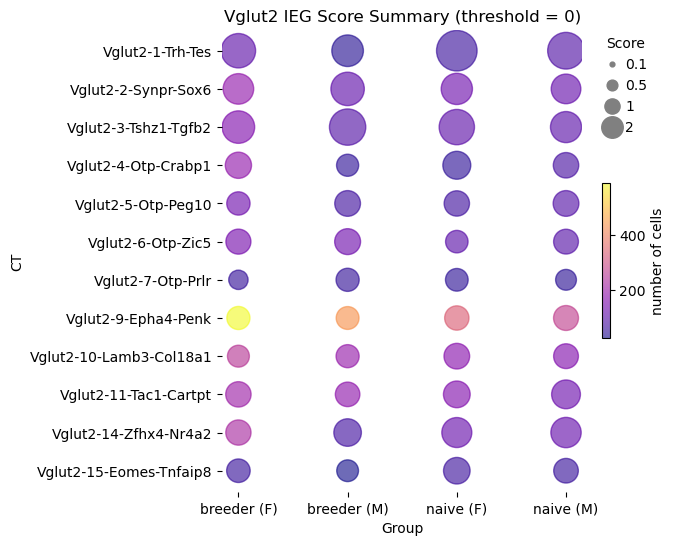

In [36]:
#module version

run = '050325_run_IEG'
cell_class = 'Vglut2'
delta_data_folder = '/bigdata/isaac/'+ cell_class + '_files/sex_stats/'+run+'/gene_delta_plots/data/'
genes = IEG_updated_list
gene_subset_name = 'IEG'
outfolder = '/bigdata/isaac/'+ cell_class + '_files/sex_stats/'+run +'/' + gene_subset_name + '_corr_plots/'
os.makedirs(outfolder, exist_ok=True)

# Change the current working directory to the specified path
os.chdir(delta_data_folder)

# Get a list of all files in the directory that include '_expr_mlog_df_c_'
raw_files = [f for f in os.listdir() if '_expr_raw_df_c_' in f]
metadata_files= [f for f in os.listdir() if '_metadata_df_c_' in f]

def extract_number(filename):
    match = re.search(r'-(\d+)-', filename)
    if match:
        return int(match.group(1))
    return float('inf')  # In case no number is found, place it at the end


# Sort the lists based on the extracted number
sorted_raw_files = sorted(raw_files, key=extract_number)
sorted_metadata_files = sorted(metadata_files, key=extract_number)

print ('sorted raw files/metadata files')
print(sorted_raw_files)
print(sorted_metadata_files)

scores_df = pd.DataFrame(columns=['fn','b_f','b_m','n_f','n_m'])
counts_df = pd.DataFrame(columns=['fn','b_f','b_m','n_f','n_m'])

for data_file, metadata_file in zip(sorted_raw_files, sorted_metadata_files):
    print (f'processing cell type: {data_file}')   
    raw_df = pd.read_json(data_file)
    metadata_df = pd.read_json(metadata_file)

    #ensure that the columns are the same
    if np.all(raw_df.columns == metadata_df.columns) != True:
        print('error: columns are not the same')
        
    #get filename
    x = data_file.split('_')
    fn = x[-1].split('.')[0]
    print('processing: ', fn)

    #check if the gene is in the raw_df
    missing_genes = []
    for g in genes:
        if g in raw_df.index:
            pass
        else:
            print (g, 'not in raw_df')
            missing_genes.append(g)

    #print ('missing genes:', missing_genes)
    #drop missing genes from original gene list
    if len(missing_genes)>0:
        print ('removing missing genes from gene list')
        genes = [x for x in genes if x not in missing_genes]

    #subset the raw_df to only include specified genes
    subset_df = raw_df.loc[genes,:]

    #drop rows with all zeros
    #subset_df = subset_df.loc[~(subset_df == 0).all(axis=1)]

    #get subset of cells for each group
    b_f_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Breeder-F']
    b_m_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Breeder-M']
    n_f_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Naïve-F']   
    n_m_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Naïve-M'] 

    #check group sizes
    cutoff = 20
    if b_f_subset_df.shape[1] <cutoff or b_m_subset_df.shape[1] <cutoff  or n_f_subset_df.shape[1] <cutoff or n_m_subset_df.shape[1] < cutoff:
        print ('one or more groups has <20 cells, skipping...')

    else:
        #use 90% quantile. i.e. 90% of cells have a value < this
        #this is the threshold for each gene
        thresh = 0
        #print (thresh)
        frac_df = pd.DataFrame(index = subset_df.index, columns = ['b_f','b_m','n_f','n_m'])
        frac_df.loc[:,'b_f'] = (b_f_subset_df>0).sum(axis=1)/b_f_subset_df.shape[1]
        frac_df.loc[:,'b_m'] = (b_m_subset_df>0).sum(axis=1)/b_m_subset_df.shape[1]
        frac_df.loc[:,'n_f'] = (n_f_subset_df>0).sum(axis=1)/n_f_subset_df.shape[1]
        frac_df.loc[:,'n_m'] = (n_m_subset_df>0).sum(axis=1)/n_m_subset_df.shape[1]


        tmp_score = pd.DataFrame({"fn": fn,
                                "b_f": frac_df.sum(axis=0)[0],
                                "b_m": frac_df.sum(axis=0)[1],
                                "n_f": frac_df.sum(axis=0)[2],
                                "n_m": frac_df.sum(axis=0)[3]}, index=[0])

        scores_df = pd.concat([scores_df,tmp_score],axis=0)

        #get counts and add to counts_df
        b_f_count = b_f_subset_df.shape[1]
        b_m_count = b_m_subset_df.shape[1]
        n_f_count = n_f_subset_df.shape[1]
        n_m_count = n_m_subset_df.shape[1]
        tmp_count = np.array([fn, b_f_count, b_m_count, n_f_count, n_m_count])
        tmp_count = np.reshape(tmp_count, (1, len(tmp_count)))
        count_df = pd.DataFrame(tmp_count, columns=counts_df.columns)
        counts_df = pd.concat([counts_df,count_df],axis=0)


scores_df.set_index('fn', inplace=True)
counts_df.set_index('fn', inplace=True)
counts_df = counts_df.astype('int')

%matplotlib inline
fig, ax = plt.subplots(figsize = (5,scores_df.values.shape[0]//2))
# Create meshgrid for x, y coordinates
x, y = np.meshgrid(np.arange(scores_df.values.shape[1]), np.arange(scores_df.values.shape[0]))

# Flatten the data array to match the shape of x and y
data_flat = scores_df.values.flatten()
counts_flat = counts_df.values.flatten()
# Plot scatter with size proportional to data values
p = ax.scatter(x, y, s=data_flat*120, c=counts_flat, cmap = 'plasma', alpha=0.6)
ax.set_ylabel('CT')
ax.set_xlabel('Group')
ax.set_yticks(np.arange(len(scores_df.index)))
ax.set_yticklabels(list(scores_df.index))
ax.set_xticks(np.arange(len(scores_df.columns)))
ax.set_xticklabels(['breeder (F)', 'breeder (M)', 'naive (F)', 'naive (M)'])
plt.colorbar(p, ax=ax, fraction = 0.02, label = 'number of cells')
ax.invert_yaxis()
# Remove border
ax.set_frame_on(False)
# Add size legend
sizes = [0.1, 0.5, 1, 2]  # Desired data values
size_scaled = [s * 120 for s in sizes]  # Match scaling from s=data*500
legend_elements = [plt.scatter([], [], s=s, label=f'{v}', c='gray') for s, v in zip(size_scaled, sizes)]
ax.legend(handles=legend_elements, title='Score', loc='upper right', bbox_to_anchor=(1.2, 1))

ax.set_title(cell_class + ' ' + gene_subset_name + ' Score Summary (threshold = 0)')
plt.savefig(outfolder + cell_class + '_' + gene_subset_name + 't0_score_summary.pdf',bbox_inches='tight')
#plt.tight_layout()
plt.show()

In [37]:
subset_df

,AGGGTCCTCCGGTTCT-1_10X35_2,AAGGAATAGTTACTCG-1_10X35_1,AGGGTTTAGTCAGGGT-1_10X35_1,GTTGTGATCCGTGTGG-1_10X35_1,TGTACAGCAGCACACC-1_10X35_1,CTCCGATGTCATTGCA-1_10X35_1,ACGTTCCGTGTCACAT-1_10X35_2,TTTCAGTTCCCGTTGT-1_10X38_1,ACTATTCGTGTGCCTG-1_10X38_1,TGGATGTCAATTTCTC-1_10X35_2,...,GACCCTTTCTACGCGG-1_10X51_4,TTTCAGTGTACTGCGC-1_10X51_4,TACATTCTCAACACCA-1_10X51_3,TGCTTGCGTACCAGAG-1_10X51_3,ATTACCTTCAAAGGAT-1_10X51_3,AGCGTCGGTATCAGGG-1_10X51_3,AACAACCCAAACCACT-1_10X51_4,AAGTTCGGTCACAGTT-1_10X51_3,TTGAGTGTCGGCCTTT-1_10X52_4,CATGCCTTCTGTCTCG-1_10X51_3
Bdnf,0.000000,0.000000,2.074904,2.365184,2.18436,4.770423,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Homer1,0.984252,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.001201,0.000000,0.000000,...,5.636449,0.000000,1.559941,0.000000,0.000000,0.000000,3.099814,1.283368,0.000000,0.000000
Fos,7.874016,0.000000,4.149808,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.325645,1.723989,0.000000,3.099814,3.850103,0.000000,3.122236
Arc,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.112347,0.000000,0.000000,0.000000,...,0.000000,2.132651,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Btg2,0.000000,0.000000,14.524328,0.000000,0.00000,0.000000,0.000000,0.000000,1.066837,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Fosl2,1.968504,0.000000,0.000000,0.000000,0.00000,0.000000,1.112347,2.002403,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.723989,0.000000,3.099814,0.000000,0.000000,0.000000
Npas4,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Nr4a1,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.001201,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.040745
Fosb,2.952756,0.000000,2.074904,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.757633,2.132651,0.000000,1.325645,0.000000,3.082614,0.000000,0.000000,0.000000,0.000000
Junb,2.952756,0.000000,14.524328,0.000000,0.00000,0.000000,2.224694,0.000000,0.000000,0.000000,...,7.515265,0.000000,0.000000,3.976934,0.000000,3.082614,0.000000,1.283368,0.000000,3.122236


In [48]:
df_orig = pd.read_feather('/bigdata/isaac/df_orig.feather')
meta_data_df = pd.read_json('/bigdata/isaac/gaba_glut_NN_combined_metadata_full_name.json')
#meta_data_df = meta_data_df.drop(['cluster_label'])
df = df_orig.reindex(columns=meta_data_df.columns)

IEG_list = []

with open('/bigdata/isaac/IEG_cluster.txt', 'r') as fh:
    for g in fh:
        IEG_list.append(g[:-1])

sex_gene_list = []

with open('/bigdata/isaac/sex_gene_list.txt', 'r') as fh:
    for g in fh:
        sex_gene_list.append(g[:-1])

#remove sex genes, IEG genes
df = dp.gene_remover(sex_gene_list,df)
#df = dp.gene_remover(IEG_list,df)

#normalize
n_factor = 20000
col_sum = np.array(df.sum(axis=0))
#print (col_sum.shape)
col_sum = np.reshape(col_sum,(1,col_sum.shape[0]))
df_norm = df.div(col_sum)
df_norm = df_norm * n_factor

groups = pd.unique(meta_data_df.loc['Group'])
full_names = pd.unique(meta_data_df.loc['full_name'])

removing  6  genes found in  ['Xist', 'Tsix', 'Ddx3y', 'Eif2s3y', 'Kdm5d', 'Uty']


In [ ]:
subset_df.quantile(0.90, axis = 1) 

In [41]:
meta_data_df.loc['cell_class']=='GABA'

CTCGAGGCATCCGTTC-1_10X52_3     True
GTCCTCACACGACCTG-1_10X52_2     True
GGCTTGGGTCGGTACC-1_10X52_2     True
GGGAGTATCAGACCTA-1_10X52_3     True
CGTGCTTTCAAAGAAC-1_10X51_2     True
                              ...  
ACACCAAAGCGTCTGC-1_10X51_4    False
AATCGACGTCATAACC-1_10X37_1    False
GAGGGATAGAACTTCC-1_10X52_2    False
TGCGGCATCAAAGAAC-1_10X52_2    False
ATCCACCCAATTTCGG-1_10X51_3    False
Name: cell_class, Length: 26269, dtype: bool

In [43]:
df_norm

,CTCGAGGCATCCGTTC-1_10X52_3,GTCCTCACACGACCTG-1_10X52_2,GGCTTGGGTCGGTACC-1_10X52_2,GGGAGTATCAGACCTA-1_10X52_3,CGTGCTTTCAAAGAAC-1_10X51_2,CGCAGGTTCGGTTAGT-1_10X52_1,CTACGGGCAGTCTCTC-1_10X51_2,AGGAGGTTCATTTGGG-1_10X35_1,ATCAGGTCACGAAGAC-1_10X36_2,CAAGGGAGTTCCACAA-1_10X38_2,...,AGGAATATCTACTTCA-1_10X52_2,CATCGTCCAAGTGGGT-1_10X52_2,ATAGGCTAGTCTGGTT-1_10X38_2,GTTACCCAGTAATCCC-1_10X36_1,AGTGATCCAGTCACGC-1_10X52_2,ACACCAAAGCGTCTGC-1_10X51_4,AATCGACGTCATAACC-1_10X37_1,GAGGGATAGAACTTCC-1_10X52_2,TGCGGCATCAAAGAAC-1_10X52_2,ATCCACCCAATTTCGG-1_10X51_3
gene,,,,,,,,,,,,,,,,,,,,,
0610007P14Rik,0.000000,3.725782,6.525285,0.000000,0.000000,0.000000,0.000000,4.276245,4.164064,0.000000,...,0.000000,0.000000,0.000000,4.165799,0.000000,0.000000,0.000000,2.644803,0.000000,0.000000
0610009B22Rik,0.000000,0.000000,0.000000,0.000000,0.000000,3.755163,0.000000,4.276245,0.000000,0.000000,...,0.000000,0.000000,4.221190,0.000000,0.000000,0.000000,3.347280,0.000000,0.000000,2.349072
0610009L18Rik,0.000000,0.000000,3.262643,0.000000,2.661698,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.377808,0.000000,2.644803,0.000000,0.000000
0610009O20Rik,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0610010F05Rik,1.970055,0.000000,0.000000,0.000000,5.323396,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.347280,5.289606,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
mt-Nd3,53.191489,59.612519,94.616639,39.603960,37.263774,37.551633,31.650122,38.486209,8.328128,52.807604,...,46.973803,61.033759,29.548333,49.989586,42.636347,131.734504,153.974895,63.475271,81.699346,23.490721
mt-Nd4,173.364854,190.014903,244.698206,251.768034,95.821134,161.472024,138.109625,175.326064,95.773475,77.451153,...,122.854562,95.365249,75.981427,91.647573,127.909042,189.157237,364.853556,169.267390,160.675381,91.613813
mt-Nd4l,17.730496,14.903130,6.525285,14.144272,23.955283,18.775817,20.140987,21.381227,0.000000,3.520507,...,10.840108,0.000000,4.221190,4.165799,7.106058,13.511231,20.083682,10.579212,8.169935,9.396288


In [60]:
gaba_norm = df_norm.loc[genes,meta_data_df.loc['cell_class']=='GABA']

In [69]:
gaba_norm

,CTCGAGGCATCCGTTC-1_10X52_3,GTCCTCACACGACCTG-1_10X52_2,GGCTTGGGTCGGTACC-1_10X52_2,GGGAGTATCAGACCTA-1_10X52_3,CGTGCTTTCAAAGAAC-1_10X51_2,CGCAGGTTCGGTTAGT-1_10X52_1,CTACGGGCAGTCTCTC-1_10X51_2,AGGAGGTTCATTTGGG-1_10X35_1,ATCAGGTCACGAAGAC-1_10X36_2,CAAGGGAGTTCCACAA-1_10X38_2,...,CCGCAAGGTGTTATCG-1_10X36_1,GCAACATAGATCGACG-1_10X51_2,ACACCAATCTACCCAC-1_10X52_2,TGCTCCAAGAGGCGTT-1_10X51_1,CGAGTGCAGGCAGTCA-1_10X37_2,GTTCGCTCACCCTCTA-1_10X35_2,AAGATAGGTAACACCT-1_10X37_2,CAACAACAGACATATG-1_10X35_2,GTAGATCGTTGACGGA-1_10X51_3,GATGAGGGTATAATGG-1_10X52_2
gene,,,,,,,,,,,,,,,,,,,,,
Bdnf,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Homer1,0.0,0.0,3.25839,0.000000,0.0,0.0,0.000000,0.000000,4.163197,0.0,...,0.902554,1.810938,2.877146,0.000000,2.243913,0.000000,0.527315,0.000000,0.000000,0.000000
Fos,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.000000,7.243752,0.959049,6.357953,1.121957,0.000000,0.000000,3.632401,1.466813,0.000000
Arc,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.210800,0.000000,0.000000
Btg2,0.0,0.0,0.00000,0.000000,0.0,0.0,5.746301,0.000000,0.000000,0.0,...,0.000000,3.621876,0.000000,4.238635,0.000000,0.000000,0.000000,8.475602,0.000000,2.080300
Fosl2,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.300851,0.000000,0.000000,0.000000,0.000000,0.000000,0.527315,0.605400,0.000000,0.000000
Npas4,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.605400,0.000000,0.000000
Nr4a1,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.210800,0.000000,0.000000
Fosb,0.0,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.000000,3.621876,0.000000,0.000000,0.000000,0.000000,0.000000,3.027001,0.000000,0.000000


In [61]:
qs = [0.50,0.60,0.70,0.80,0.90]
quat_stats = pd.DataFrame(index = genes, columns = [q for q in qs])
for q in qs:
    quat_stats.loc[:,q] = gaba_norm.loc[genes,:].quantile(q, axis = 1)

In [74]:
quat_stats

,0.5,0.6,0.7,0.8,0.9
Bdnf,0.0,0.0,0.0,0.0,0.0
Homer1,0.0,0.0,1.91957,2.700878,3.853193
Fos,0.0,0.0,0.0,1.614466,3.667706
Arc,0.0,0.0,0.0,0.0,0.0
Btg2,0.0,0.0,0.0,0.0,2.356823
Fosl2,0.0,0.0,0.0,0.0,0.0
Npas4,0.0,0.0,0.0,0.0,0.0
Nr4a1,0.0,0.0,0.0,0.0,0.981499
Fosb,0.0,0.0,0.0,0.0,0.0
Junb,0.0,0.0,2.345491,3.611412,6.48824


In [75]:
gaba_thresh = np.floor(quat_stats.loc[:,0.9])

In [104]:
gaba_thresh

Bdnf        0
Homer1      3
Fos         3
Arc         0
Btg2        2
Fosl2       0
Npas4       0
Nr4a1       0
Fosb        0
Junb        6
Egr1       10
Egr2        0
Egr4        2
Nr4a3       0
Dusp1       1
Dusp6       0
Cdkn1a      0
Gadd45b     0
Inhba       0
Name: 0.9, dtype: object

In [107]:
b_f_subset_df.gt(gaba_thresh, axis=0).sum(axis=1)/b_f_subset_df.shape[1]

Bdnf       0.016129
Homer1     0.209677
Fos        0.064516
Arc        0.048387
Btg2       0.016129
Fosl2      0.016129
Npas4      0.048387
Nr4a1      0.000000
Fosb       0.032258
Junb       0.032258
Egr1       0.064516
Egr2       0.000000
Egr4       0.032258
Nr4a3      0.032258
Dusp1      0.129032
Dusp6      0.032258
Cdkn1a     0.161290
Gadd45b    0.032258
Inhba      0.000000
dtype: float64

In [94]:
b_f_subset_df.loc['Bdnf',:]

CTGTAGACAAAGACGC-1_10X51_1    0.0
AGCGCCACATCTTTCA-1_10X52_2    0.0
GTGTAACGTCCGGTGT-1_10X51_2    0.0
ACTATGGAGCATGCGA-1_10X51_2    0.0
CACTGAAGTGAATTGA-1_10X52_2    0.0
                             ... 
CGTTCTGCAGAATCGG-1_10X51_2    0.0
GATGACTTCTGCTGAA-1_10X51_2    0.0
TCCCATGGTTTACGAC-1_10X52_1    0.0
TGGTACACATGTTACG-1_10X51_1    0.0
CATACAGAGAGAGCAA-1_10X52_1    0.0
Name: Bdnf, Length: 70, dtype: float64

In [96]:
gaba_thresh.loc['Bdnf']

0

In [102]:
np.where(b_f_subset_df.loc['Bdnf',:]>gaba_thresh.loc['Bdnf'])

(array([10, 54]),)

In [77]:
b_f_subset_df>gaba_thresh.sum(axis=1)/b_f_subset_df.shape[1]

ValueError: No axis named 1 for object type Series

In [111]:
outfolder

'/bigdata/isaac/gaba_files/sex_stats/050325_run_IEG/IEG_corr_plots/'

In [139]:
#debug single cell type

run = '050325_run_IEG'
cell_class = 'gaba'
delta_data_folder = '/bigdata/isaac/'+ cell_class + '_files/sex_stats/'+run+'/gene_delta_plots/data/'
genes = IEG_updated_list
gene_subset_name = 'IEG'
outfolder = '/bigdata/isaac/'+ cell_class + '_files/sex_stats/'+run +'/' + gene_subset_name + '_corr_plots/'
os.makedirs(outfolder, exist_ok=True)

# Change the current working directory to the specified path
os.chdir(delta_data_folder)

# Get a list of all files in the directory that include '_expr_mlog_df_c_'
raw_files = [f for f in os.listdir() if '_expr_raw_df_c_' in f]
metadata_files= [f for f in os.listdir() if '_metadata_df_c_' in f]

def extract_number(filename):
    match = re.search(r'-(\d+)-', filename)
    if match:
        return int(match.group(1))
    return float('inf')  # In case no number is found, place it at the end


# Sort the lists based on the extracted number
sorted_raw_files = sorted(raw_files, key=extract_number)
sorted_metadata_files = sorted(metadata_files, key=extract_number)


#use 90th percentile over all gaba cells, rounded down
gaba_thresh = np.floor(quat_stats.loc[:,0.9])
frac_output_folder = outfolder+'frac_per_ct/'
os.makedirs(frac_output_folder, exist_ok=True)

scores_df = pd.DataFrame(columns=['fn','b_f','b_m','n_f','n_m'])
counts_df = pd.DataFrame(columns=['fn','b_f','b_m','n_f','n_m'])

data_file = sorted_raw_files[1]
metadata_file = sorted_metadata_files[1]
print (data_file)
raw_df = pd.read_json(data_file)
metadata_df = pd.read_json(metadata_file)

#ensure that the columns are the same
if np.all(raw_df.columns == metadata_df.columns) != True:
    print('error: columns are not the same')
    
#get filename
x = data_file.split('_')
fn = x[-1].split('.')[0]
print('processing: ', fn)

#check if the gene is in the raw_df
missing_genes = []
for g in genes:
    if g in raw_df.index:
        pass
    else:
        print (g, 'not in raw_df')
        missing_genes.append(g)

#print ('missing genes:', missing_genes)
#drop missing genes from original gene list
if len(missing_genes)>0:
    print ('removing missing genes from gene list')
    genes = [x for x in genes if x not in missing_genes]

#subset the raw_df to only include specified genes
subset_df = raw_df.loc[genes,:]

#drop rows with all zeros
#subset_df = subset_df.loc[~(subset_df == 0).all(axis=1)]

#get subset of cells for each group
b_f_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Breeder-F']
b_m_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Breeder-M']
n_f_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Naïve-F']   
n_m_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Naïve-M'] 

#check group sizes
cutoff = 20
if b_f_subset_df.shape[1] <cutoff or b_m_subset_df.shape[1] <cutoff  or n_f_subset_df.shape[1] <cutoff or n_m_subset_df.shape[1] < cutoff:
    print ('one or more groups has <20 cells, skipping...')

else:
    #use 90% quantile. i.e. 90% of cells have a value < this
    #this is the threshold for each gene

    #simple case - make thresh 0 for all genes
    #thresh = 0
    
    frac_df = pd.DataFrame(index = subset_df.index, columns = ['b_f','b_m','n_f','n_m'])
    frac_df.loc[:,'b_f'] = b_f_subset_df.gt(gaba_thresh, axis=0).sum(axis=1)/b_f_subset_df.shape[1]
    frac_df.loc[:,'b_m'] = b_m_subset_df.gt(gaba_thresh, axis=0).sum(axis=1)/b_m_subset_df.shape[1]
    frac_df.loc[:,'n_f'] = n_f_subset_df.gt(gaba_thresh, axis=0).sum(axis=1)/n_f_subset_df.shape[1]
    frac_df.loc[:,'n_m'] = n_m_subset_df.gt(gaba_thresh, axis=0).sum(axis=1)/n_m_subset_df.shape[1]


    #calculate the fraction of cells above the threshold
    #for g in genes:
        #b_f_frac = (b_f_subset_df.loc[g,:] > thresh_df.loc[g]).sum()/b_f_subset_df.shape[1]
        #b_m_frac = (b_m_subset_df.loc[g,:] > thresh_df.loc[g]).sum()/b_m_subset_df.shape[1]
        #n_f_frac = (n_f_subset_df.loc[g,:] > thresh_df.loc[g]).sum()/n_f_subset_df.shape[1]
        #n_m_frac = (n_m_subset_df.loc[g,:] > thresh_df.loc[g]).sum()/n_m_subset_df.shape[1]
        
        #frac_df.loc[g,'b_f'] = b_f_frac
        #frac_df.loc[g,'b_m'] = b_m_frac
        #frac_df.loc[g,'n_f'] = n_f_frac
        #frac_df.loc[g,'n_m'] = n_m_frac

    #print (frac_df)
    #tmp_score = pd.DataFrame({"fn": fn,
    #                        "b_f": frac_df.sum(axis=0)[0],
    #                        "b_m": frac_df.sum(axis=0)[1],
    #                        "n_f": frac_df.sum(axis=0)[2],
    #                        "n_m": frac_df.sum(axis=0)[3]}, index=[0])

    #single gene
    gene = 'Fos'
    tmp_score = pd.DataFrame({"fn": fn,
                            "b_f": frac_df.loc[gene,'b_f'],
                            "b_m": frac_df.loc[gene,'b_m'],
                            "n_f": frac_df.loc[gene,'n_f'],
                            "n_m": frac_df.loc[gene,'n_m']}, index=[0])

    scores_df = pd.concat([scores_df,tmp_score],axis=0)

    #get counts and add to counts_df
    b_f_count = b_f_subset_df.shape[1]
    b_m_count = b_m_subset_df.shape[1]
    n_f_count = n_f_subset_df.shape[1]
    n_m_count = n_m_subset_df.shape[1]
    tmp_count = np.array([fn, b_f_count, b_m_count, n_f_count, n_m_count])
    tmp_count = np.reshape(tmp_count, (1, len(tmp_count)))
    count_df = pd.DataFrame(tmp_count, columns=counts_df.columns)
    counts_df = pd.concat([counts_df,count_df],axis=0)

    #frac_df.to_csv(frac_output_folder + fn + '_frac_df.csv')

gaba_expr_raw_df_c_GABA-2-Sst-Npy-Maf.json
processing:  GABA-2-Sst-Npy-Maf


sorted raw files/metadata files
['gaba_expr_raw_df_c_GABA-1-Sst-Npy-Spon1.json', 'gaba_expr_raw_df_c_GABA-2-Sst-Npy-Maf.json', 'gaba_expr_raw_df_c_GABA-3-Sst-Npy-Chodl.json', 'gaba_expr_raw_df_c_GABA-4-Moxd1-Pvalb.json', 'gaba_expr_raw_df_c_GABA-5-Moxd1-Vwc2.json', 'gaba_expr_raw_df_c_GABA-6-Hapln1-Cryab.json', 'gaba_expr_raw_df_c_GABA-7-Vip-Crh.json', 'gaba_expr_raw_df_c_GABA-8-Htr3a-Rgs12.json', 'gaba_expr_raw_df_c_GABA-9-Dab1-Myh7.json', 'gaba_expr_raw_df_c_GABA-10-Pax6-Npnt.json', 'gaba_expr_raw_df_c_GABA-11-Pax6-Calca.json', 'gaba_expr_raw_df_c_GABA-12-Sncg-Reln.json', 'gaba_expr_raw_df_c_GABA-13-Fign-Lrpprc.json', 'gaba_expr_raw_df_c_GABA-14-Isl1-Gal.json', 'gaba_expr_raw_df_c_GABA-15-Igsf1-Zfhx3.json', 'gaba_expr_raw_df_c_GABA-16-Lmo1-Chn2.json', 'gaba_expr_raw_df_c_GABA-17-Isl1-Pou3f2.json', 'gaba_expr_raw_df_c_GABA-18-Meis2-Dach1.json', 'gaba_expr_raw_df_c_GABA-19-Meis2-Tshz1.json', 'gaba_expr_raw_df_c_GABA-20-Meis2-Foxp2.json', 'gaba_expr_raw_df_c_GABA-21-Meis2-Nwd2.json', 'g

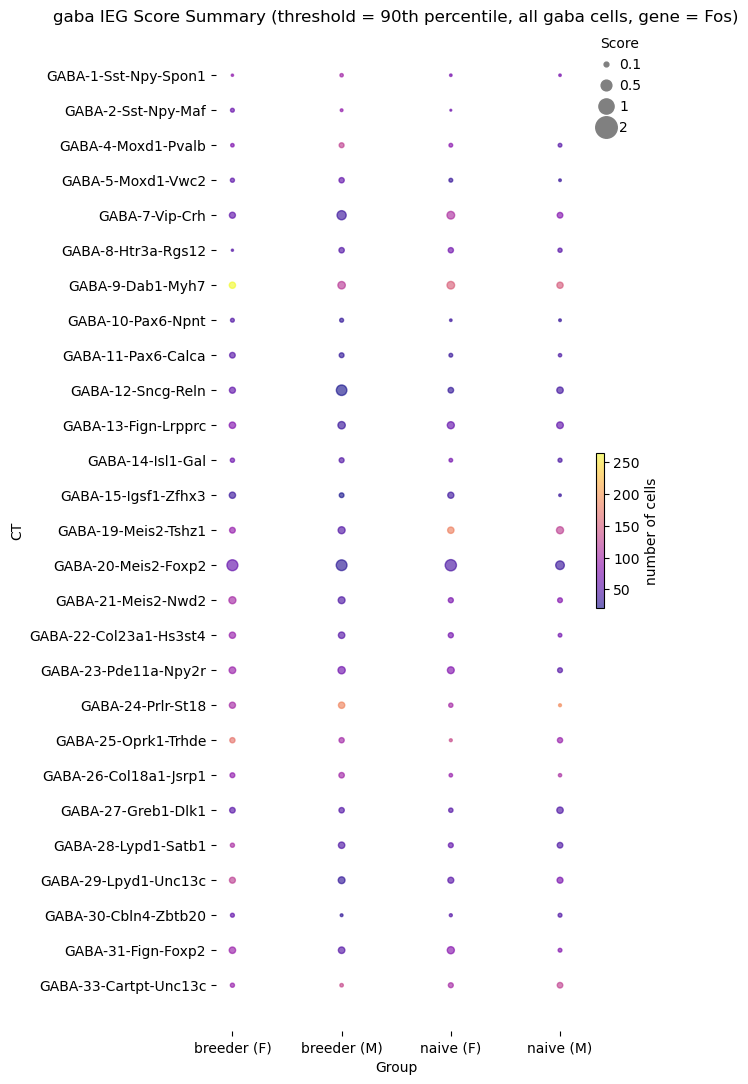

In [ ]:
run = '050325_run_IEG'
cell_class = 'gaba'
delta_data_folder = '/bigdata/isaac/'+ cell_class + '_files/sex_stats/'+run+'/gene_delta_plots/data/'
genes = IEG_updated_list
gene_subset_name = 'IEG'
outfolder = '/bigdata/isaac/'+ cell_class + '_files/sex_stats/'+run +'/' + gene_subset_name + '_corr_plots/'
single_gene = True
if single_gene:
    gene = 'Fos'

os.makedirs(outfolder, exist_ok=True)

# Change the current working directory to the specified path
os.chdir(delta_data_folder)

# Get a list of all files in the directory that include '_expr_mlog_df_c_'
raw_files = [f for f in os.listdir() if '_expr_raw_df_c_' in f]
metadata_files= [f for f in os.listdir() if '_metadata_df_c_' in f]

def extract_number(filename):
    match = re.search(r'-(\d+)-', filename)
    if match:
        return int(match.group(1))
    return float('inf')  # In case no number is found, place it at the end


# Sort the lists based on the extracted number
sorted_raw_files = sorted(raw_files, key=extract_number)
sorted_metadata_files = sorted(metadata_files, key=extract_number)

print ('sorted raw files/metadata files')
print(sorted_raw_files)
print(sorted_metadata_files)

gaba_thresh = np.floor(quat_stats.loc[:,0.9])
frac_output_folder = outfolder+'frac_per_ct/'
os.makedirs(frac_output_folder, exist_ok=True)

scores_df = pd.DataFrame(columns=['fn','b_f','b_m','n_f','n_m'])
counts_df = pd.DataFrame(columns=['fn','b_f','b_m','n_f','n_m'])

for data_file, metadata_file in zip(sorted_raw_files, sorted_metadata_files):
    print (f'processing cell type: {data_file}')   
    raw_df = pd.read_json(data_file)
    metadata_df = pd.read_json(metadata_file)


    #ensure that the columns are the same
    if np.all(raw_df.columns == metadata_df.columns) != True:
        print('error: columns are not the same')
        
    #get filename
    x = data_file.split('_')
    fn = x[-1].split('.')[0]
    print('processing: ', fn)

    #check if the gene is in the raw_df
    missing_genes = []
    for g in genes:
        if g in raw_df.index:
            pass
        else:
            print (g, 'not in raw_df')
            missing_genes.append(g)

    #print ('missing genes:', missing_genes)
    #drop missing genes from original gene list
    if len(missing_genes)>0:
        print ('removing missing genes from gene list')
        genes = [x for x in genes if x not in missing_genes]

    #subset the raw_df to only include specified genes
    subset_df = raw_df.loc[genes,:]

    #drop rows with all zeros
    #subset_df = subset_df.loc[~(subset_df == 0).all(axis=1)]

    #get subset of cells for each group
    b_f_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Breeder-F']
    b_m_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Breeder-M']
    n_f_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Naïve-F']   
    n_m_subset_df = subset_df.loc[:,metadata_df.loc['Group'] == 'Naïve-M'] 

    #check group sizes
    cutoff = 20
    if b_f_subset_df.shape[1] <cutoff or b_m_subset_df.shape[1] <cutoff  or n_f_subset_df.shape[1] <cutoff or n_m_subset_df.shape[1] < cutoff:
        print ('one or more groups has <20 cells, skipping...')

    else:
        #use 90% quantile. i.e. 90% of cells have a value < this
        #this is the threshold for each gene

        #simple case - make thresh 0 for all genes
        #thresh = 0
        
        frac_df = pd.DataFrame(index = subset_df.index, columns = ['b_f','b_m','n_f','n_m'])
        frac_df.loc[:,'b_f'] = b_f_subset_df.gt(gaba_thresh, axis=0).sum(axis=1)/b_f_subset_df.shape[1]
        frac_df.loc[:,'b_m'] = b_m_subset_df.gt(gaba_thresh, axis=0).sum(axis=1)/b_m_subset_df.shape[1]
        frac_df.loc[:,'n_f'] = n_f_subset_df.gt(gaba_thresh, axis=0).sum(axis=1)/n_f_subset_df.shape[1]
        frac_df.loc[:,'n_m'] = n_m_subset_df.gt(gaba_thresh, axis=0).sum(axis=1)/n_m_subset_df.shape[1]

        #print (frac_df)
        if single_gene:
            tmp_score = pd.DataFrame({"fn": fn,
                            "b_f": frac_df.loc[gene,'b_f'],
                            "b_m": frac_df.loc[gene,'b_m'],
                            "n_f": frac_df.loc[gene,'n_f'],
                            "n_m": frac_df.loc[gene,'n_m']}, index=[0])
        else:
            tmp_score = pd.DataFrame({"fn": fn,
                                "b_f": frac_df.sum(axis=0)[0],
                                "b_m": frac_df.sum(axis=0)[1],
                                "n_f": frac_df.sum(axis=0)[2],
                                "n_m": frac_df.sum(axis=0)[3]}, index=[0])

        scores_df = pd.concat([scores_df,tmp_score],axis=0)

        #get counts and add to counts_df
        b_f_count = b_f_subset_df.shape[1]
        b_m_count = b_m_subset_df.shape[1]
        n_f_count = n_f_subset_df.shape[1]
        n_m_count = n_m_subset_df.shape[1]
        tmp_count = np.array([fn, b_f_count, b_m_count, n_f_count, n_m_count])
        tmp_count = np.reshape(tmp_count, (1, len(tmp_count)))
        count_df = pd.DataFrame(tmp_count, columns=counts_df.columns)
        counts_df = pd.concat([counts_df,count_df],axis=0)

        frac_df.to_csv(frac_output_folder + fn + '_frac_df.csv')

scores_df.set_index('fn', inplace=True)
counts_df.set_index('fn', inplace=True)
counts_df = counts_df.astype('int')

%matplotlib inline
fig, ax = plt.subplots(figsize = (5,scores_df.values.shape[0]//2))
# Create meshgrid for x, y coordinates
x, y = np.meshgrid(np.arange(scores_df.values.shape[1]), np.arange(scores_df.values.shape[0]))

# Flatten the data array to match the shape of x and y
data_flat = scores_df.values.flatten()
counts_flat = counts_df.values.flatten()
# Plot scatter with size proportional to data values
p = ax.scatter(x, y, s=data_flat*120, c=counts_flat, cmap = 'plasma', alpha=0.6)
ax.set_ylabel('CT')
ax.set_xlabel('Group')
ax.set_yticks(np.arange(len(scores_df.index)))
ax.set_yticklabels(list(scores_df.index))
ax.set_xticks(np.arange(len(scores_df.columns)))
ax.set_xticklabels(['breeder (F)', 'breeder (M)', 'naive (F)', 'naive (M)'])
plt.colorbar(p, ax=ax, fraction = 0.02, label = 'number of cells')
ax.invert_yaxis()
# Remove border
ax.set_frame_on(False)
# Add size legend
sizes = [0.1, 0.5, 1, 2]  # Desired data values
size_scaled = [s * 120 for s in sizes]  # Match scaling from s=data*500
legend_elements = [plt.scatter([], [], s=s, label=f'{v}', c='gray') for s, v in zip(size_scaled, sizes)]
ax.legend(handles=legend_elements, title='Score', loc='upper right', bbox_to_anchor=(1.2, 1))


if single_gene: 
    ax.set_title(cell_class + ' ' + gene_subset_name + ' Score Summary (threshold = 90th percentile, all gaba cells, gene = ' + gene + ')')
    plt.savefig(frac_output_folder + cell_class + '_' + gene_subset_name + 'score_summary_' + gene + '.pdf',bbox_inches='tight')
else:
    ax.set_title(cell_class + ' ' + gene_subset_name + ' Score Summary (threshold = 90th percentile, all gaba cells)')
    plt.savefig(outfolder + cell_class + '_' + gene_subset_name + 'score_summary.pdf',bbox_inches='tight')
#plt.tight_layout()
plt.show()

In [151]:
scores_df

,b_f,b_m,n_f,n_m
fn,,,,
GABA-1-Sst-Npy-Spon1,0.022989,0.049020,0.027778,0.027397
GABA-2-Sst-Npy-Maf,0.064516,0.032967,0.015152,0.000000
GABA-4-Moxd1-Pvalb,0.051948,0.103175,0.059524,0.060000
GABA-5-Moxd1-Vwc2,0.072727,0.120690,0.062500,0.030303
GABA-7-Vip-Crh,0.157895,0.361111,0.254545,0.137500
GABA-8-Htr3a-Rgs12,0.020408,0.125000,0.119403,0.076923
GABA-9-Dab1-Myh7,0.169811,0.239669,0.248366,0.167785
GABA-10-Pax6-Npnt,0.063830,0.066667,0.027778,0.031250
GABA-11-Pax6-Calca,0.137255,0.100000,0.060606,0.047619


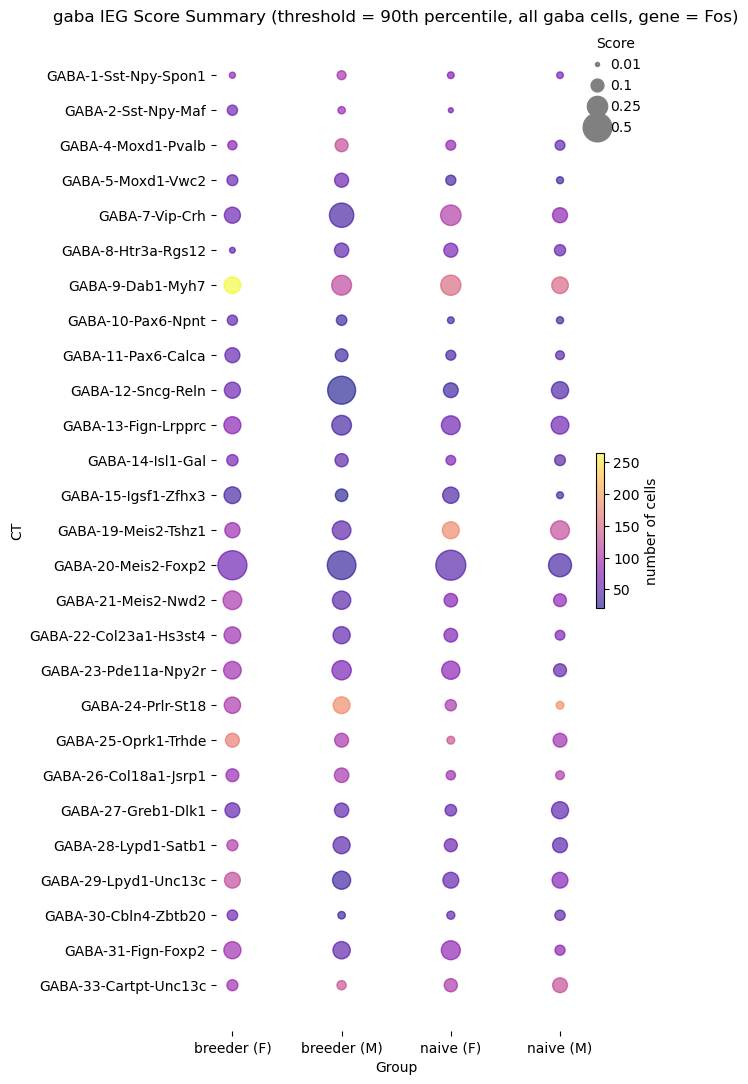

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize = (5,scores_df.values.shape[0]//2))
# Create meshgrid for x, y coordinates
x, y = np.meshgrid(np.arange(scores_df.values.shape[1]), np.arange(scores_df.values.shape[0]))

# Flatten the data array to match the shape of x and y
data_flat = scores_df.values.flatten()
counts_flat = counts_df.values.flatten()
# Plot scatter with size proportional to data values
if single_gene:
    scale_f = 850
else:
    scale_f = 120
p = ax.scatter(x, y, s=data_flat*scale_f, c=counts_flat, cmap = 'plasma', alpha=0.6)
ax.set_ylabel('CT')
ax.set_xlabel('Group')
ax.set_yticks(np.arange(len(scores_df.index)))
ax.set_yticklabels(list(scores_df.index))
ax.set_xticks(np.arange(len(scores_df.columns)))
ax.set_xticklabels(['breeder (F)', 'breeder (M)', 'naive (F)', 'naive (M)'])
plt.colorbar(p, ax=ax, fraction = 0.02, label = 'number of cells')
ax.invert_yaxis()
# Remove border
ax.set_frame_on(False)
# Add size legend
if single_gene:
    sizes = [0.01,0.1,0.25,0.5]
else:
    sizes = [0.1, 0.5, 1, 2]  # Desired data values
size_scaled = [s * scale_f for s in sizes]  # Match scaling from s=data*500
legend_elements = [plt.scatter([], [], s=s, label=f'{v}', c='gray') for s, v in zip(size_scaled, sizes)]
ax.legend(handles=legend_elements, title='Score', loc='upper right', bbox_to_anchor=(1.2, 1))


if single_gene: 
    ax.set_title(cell_class + ' ' + gene_subset_name + ' Score Summary (threshold = 90th percentile, all gaba cells, gene = ' + gene + ')')
    plt.savefig(frac_output_folder + cell_class + '_' + gene_subset_name + 'score_summary_' + gene + '.pdf',bbox_inches='tight')
else:
    ax.set_title(cell_class + ' ' + gene_subset_name + ' Score Summary (threshold = 90th percentile, all gaba cells)')
    plt.savefig(outfolder + cell_class + '_' + gene_subset_name + 'score_summary.pdf',bbox_inches='tight')
#plt.tight_layout()
plt.show()

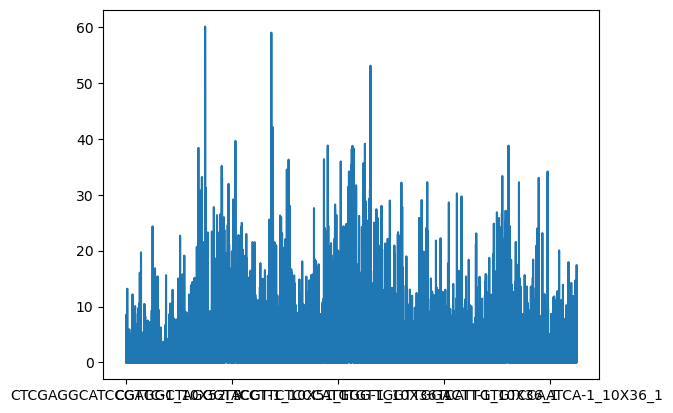

In [68]:
%matplotlib inline
gaba_norm.loc['Egr1',:].plot(kind='line')
plt.show()